In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Files found: ['C:\\Users\\Dindo\\Documents\\aqpx\\Cabrera_Thesis_AQPX\\Preliminary_Data_Analysis\\AQPX_data_log_2026-02-08.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\Cabrera_Thesis_AQPX\\Preliminary_Data_Analysis\\AQPX_data_log_2026-02-09.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\Cabrera_Thesis_AQPX\\Preliminary_Data_Analysis\\AQPX_data_log_2026-02-10.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\Cabrera_Thesis_AQPX\\Preliminary_Data_Analysis\\AQPX_data_log_2026-02-11.csv', 'C:\\Users\\Dindo\\Documents\\aqpx\\Cabrera_Thesis_AQPX\\Preliminary_Data_Analysis\\AQPX_data_log_2026-02-12.csv']
Loading: C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-08.csv
Loading: C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-09.csv
Loading: C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-10.csv
Loading: C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminar

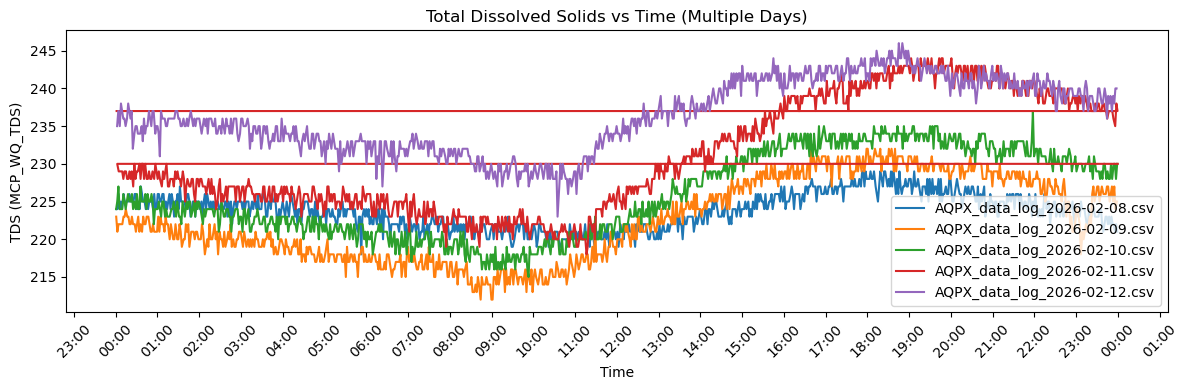

In [2]:
import glob

# ---- SETTINGS ----
folder = r"C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis"
downsample_factor = 20

# ---- FIND ALL CSV FILES ----
csv_files = glob.glob(f"{folder}/*.csv")

print("Files found:", csv_files)

plt.figure(figsize=(12, 4))

# ---- PROCESS EACH FILE ----
for file in csv_files:
    print("Loading:", file)

    df = pd.read_csv(file)

    # Convert Time column
    df["Time"] = df["Time"].astype(str).str.strip()
    dtime = pd.to_datetime("2025-12-17 " + df["Time"], errors="coerce")

    # Get TDS values
    dtds = df["MCP_WQ_TDS"]

    # Downsample (optional)
    dtime_small = dtime[::downsample_factor]
    dtds_small = dtds[::downsample_factor]

    # Plot each CSV
    plt.plot(dtime_small, dtds_small, label=file.split("\\")[-1])

# ---- GRAPH SETTINGS ----
plt.xlabel("Time")
plt.ylabel("TDS (MCP_WQ_TDS)")
plt.title("Total Dissolved Solids vs Time (Multiple Days)")

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Files found:
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-17.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-18.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-19.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-20.csv
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-17.csv (date: 2026-01-17)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-18.csv (date: 2026-01-18)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-19.csv (date: 2026-01-19)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-01-20.csv (date: 2026-01-20)

Stitched dataframe preview

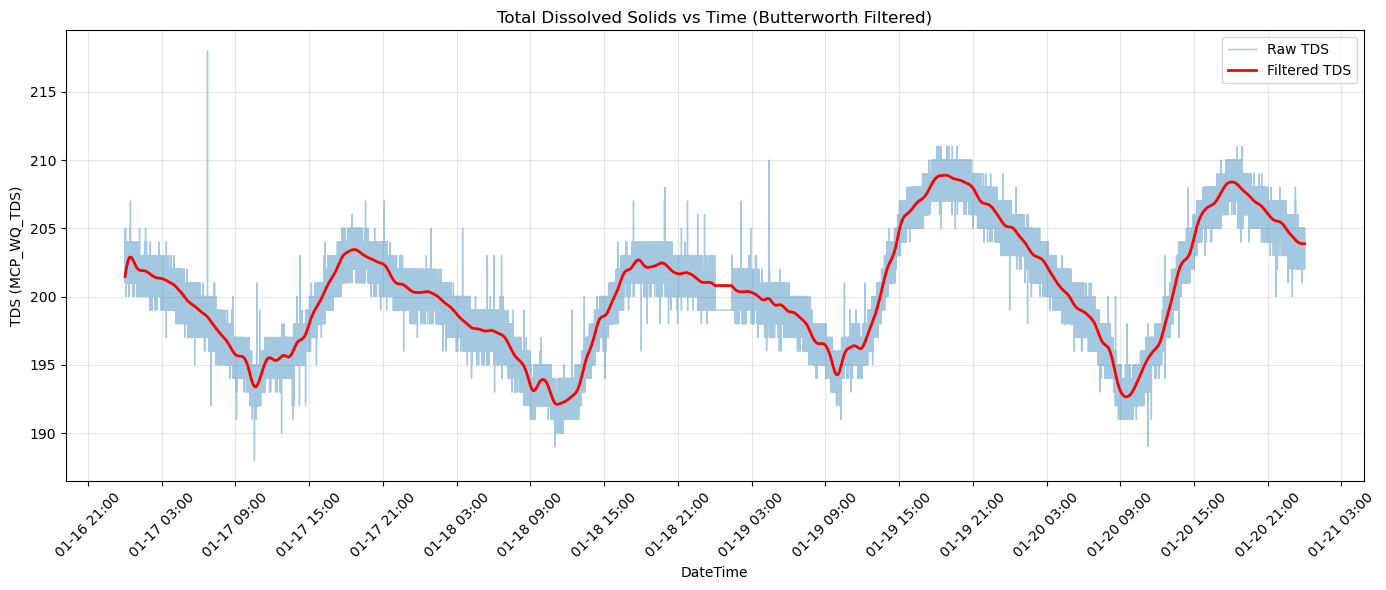


Filtering complete. Data range:
  Raw: 188.00 to 218.00
  Filtered: 192.10 to 208.89


In [11]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, sosfiltfilt

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis"
# Find all CSV files
csv_files = glob.glob(f"{folder}/*.csv")
print("Files found:")
for f in csv_files:
    print(" -", f)

frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:
    # Extract date from filename (YYYY-MM-DD)
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")
    
    print(f"Loading {file} (date: {date_str})")
    # Load CSV
    df = pd.read_csv(file)
    # Fix Time column
    df["Time"] = df["Time"].astype(str).str.strip()
    # Combine date + time
    df["DateTime"] = pd.to_datetime(
        date_str + " " + df["Time"],
        errors="coerce"
    )
    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)
# Sort chronologically (important!)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# --------------------------------
# 4. COMPUTE SAMPLING FREQUENCY (fs)
# --------------------------------
dt_seconds = full_df["DateTime"].diff().dt.total_seconds().median()
fs = 1.0 / dt_seconds
print(f"\nEstimated sampling frequency: {fs:.6f} Hz "
      f"(Δt ≈ {dt_seconds:.2f} s)")

# --------------------------------
# 5. DESIGN BUTTERWORTH SOS FILTER
# --------------------------------
# Choose cutoff based on what you want to preserve:
# - For hourly trends: cutoff = 1/(3600*2) ≈ 0.00014 Hz
# - For 30-min trends: cutoff = 1/(1800*2) ≈ 0.00028 Hz
# - For 15-min trends: cutoff = 1/(900*2) ≈ 0.00056 Hz

cutoff = 1.0 / (1800 * 2)  # Remove fluctuations faster than ~2 hours
order = 4

# Safety check
nyquist = fs / 2
if cutoff >= nyquist:
    print(f"WARNING: Cutoff {cutoff:.6f} Hz >= Nyquist {nyquist:.6f} Hz")
    cutoff = nyquist * 0.8  # Set to 80% of Nyquist
    print(f"Adjusting cutoff to {cutoff:.6f} Hz")

print(f"Filter cutoff: {cutoff:.6f} Hz (period: {1/cutoff/60:.1f} minutes)")

sos = butter(
    N=order,
    Wn=cutoff,
    btype="low",
    fs=fs,
    output="sos"
)

# --------------------------------
# 6. APPLY FILTER (with NaN handling)
# --------------------------------
tds = full_df["MCP_WQ_TDS"].astype(float).values

# Check for NaNs
if np.any(np.isnan(tds)):
    print(f"WARNING: Found {np.sum(np.isnan(tds))} NaN values. Interpolating...")
    tds = pd.Series(tds).interpolate(method='linear').values

tds_filtered = sosfiltfilt(sos, tds)
full_df["TDS_filtered"] = tds_filtered

# --------------------------------
# 7. PLOT RAW VS FILTERED (ALL DATA)
# --------------------------------
plt.figure(figsize=(14, 6))

plt.plot(full_df["DateTime"], full_df["MCP_WQ_TDS"], 
         label="Raw TDS", alpha=0.4, linewidth=1)
plt.plot(full_df["DateTime"], full_df["TDS_filtered"],
         label="Filtered TDS", linewidth=2, color='red')

plt.title("Total Dissolved Solids vs Time (Butterworth Filtered)")
plt.xlabel("DateTime")
plt.ylabel("TDS (MCP_WQ_TDS)")
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFiltering complete. Data range:")
print(f"  Raw: {full_df['MCP_WQ_TDS'].min():.2f} to {full_df['MCP_WQ_TDS'].max():.2f}")
print(f"  Filtered: {full_df['TDS_filtered'].min():.2f} to {full_df['TDS_filtered'].max():.2f}")

In [10]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, sosfiltfilt

# ================================
# GENERALIZED FUNCTIONS
# ================================

def design_butterworth_filter(fs, period_hours=None, period_minutes=None, period_seconds=None, order=4):
    """
    Design a Butterworth low-pass filter based on the PERIOD you want to preserve.
    
    Parameters:
    -----------
    fs : float
        Sampling frequency in Hz
    period_hours : float, optional
        Minimum period to preserve in hours (e.g., 2 means keep variations slower than 2 hours)
    period_minutes : float, optional
        Minimum period to preserve in minutes
    period_seconds : float, optional
        Minimum period to preserve in seconds
    order : int
        Filter order (default: 4)
    
    Returns:
    --------
    sos : array
        Second-order sections representation of the filter
    cutoff : float
        The actual cutoff frequency used (in Hz)
    period_used : float
        The period used (in seconds)
    
    Note: Provide only ONE of period_hours, period_minutes, or period_seconds
    """
    # Convert period to seconds
    if period_hours is not None:
        period_sec = period_hours * 3600
    elif period_minutes is not None:
        period_sec = period_minutes * 60
    elif period_seconds is not None:
        period_sec = period_seconds
    else:
        raise ValueError("Must specify one of: period_hours, period_minutes, or period_seconds")
    
    # Convert period to frequency
    # Using 2x safety factor: cutoff at half the period
    cutoff = 1.0 / (period_sec * 2)
    
    # Safety check against Nyquist
    nyquist = fs / 2
    if cutoff >= nyquist:
        print(f"WARNING: Requested cutoff {cutoff:.6f} Hz >= Nyquist {nyquist:.6f} Hz")
        cutoff = nyquist * 0.8
        actual_period = 1.0 / cutoff
        print(f"Adjusting to {cutoff:.6f} Hz (period: {actual_period/60:.1f} minutes)")
    
    # Design filter
    sos = butter(N=order, Wn=cutoff, btype="low", fs=fs, output="sos")
    
    print(f"\nFilter designed:")
    print(f"  Preserves variations SLOWER than {period_sec/60:.1f} minutes")
    print(f"  Removes variations FASTER than {period_sec/60:.1f} minutes")
    print(f"  Cutoff frequency: {cutoff:.6f} Hz")
    
    return sos, cutoff, period_sec


def apply_butterworth_filter(df, column_name, sos, output_column_name=None):
    """
    Apply Butterworth filter to a specified column with NaN handling.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    column_name : str
        Name of column to filter (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    sos : array
        Second-order sections representation of the IIR filter
    output_column_name : str, optional
        Name for filtered output column. If None, uses "{column_name}_filtered"
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with added filtered column
    """
    if output_column_name is None:
        output_column_name = f"{column_name}_filtered"
    
    # Extract data
    data = df[column_name].astype(float).values
    
    # Check for NaNs
    if np.any(np.isnan(data)):
        nan_count = np.sum(np.isnan(data))
        print(f"WARNING: Found {nan_count} NaN values in {column_name}. Interpolating...")
        data = pd.Series(data).interpolate(method='linear').values
    
    # Apply filter
    data_filtered = sosfiltfilt(sos, data)
    df[output_column_name] = data_filtered
    
    return df


def plot_filtered_data(df, column_name, filtered_column_name=None, 
                       title=None, ylabel=None, 
                       figsize=(14, 6), hour_interval=6):
    """
    Plot filtered data only.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing DateTime and data columns
    column_name : str
        Name of raw data column (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    filtered_column_name : str, optional
        Name of filtered data column. If None, uses "{column_name}_filtered"
    title : str, optional
        Plot title. If None, auto-generated
    ylabel : str, optional
        Y-axis label. If None, uses column_name
    figsize : tuple
        Figure size (width, height)
    hour_interval : int
        Hour interval for x-axis ticks
    """
    if filtered_column_name is None:
        filtered_column_name = f"{column_name}_filtered"
    
    # Auto-generate labels if not provided
    if title is None:
        param_name = column_name.replace("MCP_WQ_", "")
        param_full = {
            "TDS": "Total Dissolved Solids",
            "EC": "Electrical Conductivity"
        }.get(param_name, param_name)
        title = f"{param_full} vs Time (Butterworth Filtered)"
    
    if ylabel is None:
        ylabel = column_name
    
    # Create plot
    plt.figure(figsize=figsize)
    
    plt.plot(df["DateTime"], df[filtered_column_name],
             label=f"Filtered {column_name.replace('MCP_WQ_', '')}", 
             linewidth=2, color='red')
    
    plt.title(title)
    plt.xlabel("DateTime")
    plt.ylabel(ylabel)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=hour_interval))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFiltering complete for {column_name}:")
    print(f"  Raw: {df[column_name].min():.2f} to {df[column_name].max():.2f}")
    print(f"  Filtered: {df[filtered_column_name].min():.2f} to {df[filtered_column_name].max():.2f}")


def process_and_plot(df, column_name, sos, 
                     filtered_column_name=None,
                     title=None, ylabel=None,
                     figsize=(14, 6), hour_interval=6):
    """
    Convenience function: apply filter and plot in one call.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    column_name : str
        Name of column to filter (e.g., "MCP_WQ_TDS", "MCP_WQ_EC")
    sos : array
        Second-order sections representation of the IIR filter
    filtered_column_name : str, optional
        Name for filtered output column
    title : str, optional
        Plot title
    ylabel : str, optional
        Y-axis label
    figsize : tuple
        Figure size
    hour_interval : int
        Hour interval for x-axis ticks
    
    Returns:
    --------
    pd.DataFrame
        Dataframe with added filtered column
    """
    df = apply_butterworth_filter(df, column_name, sos, filtered_column_name)
    plot_filtered_data(df, column_name, filtered_column_name, 
                      title, ylabel, figsize, hour_interval)
    return df


def plot_overlay(df, column_names, filtered_column_names=None,
                 title=None, ylabel=None, 
                 figsize=(14, 6), hour_interval=6,
                 colors=None, labels=None):
    """
    Plot multiple filtered data series overlaid on the same graph.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing DateTime and data columns
    column_names : list of str
        List of column names to overlay (e.g., ["MCP_WQ_TDS", "MCP_WQ_EC"])
    filtered_column_names : list of str, optional
        List of filtered column names. If None, uses "{column_name}_filtered" for each
    title : str, optional
        Plot title. If None, auto-generated
    ylabel : str, optional
        Y-axis label. If None, auto-generated
    figsize : tuple
        Figure size (width, height)
    hour_interval : int
        Hour interval for x-axis ticks
    colors : list of str, optional
        List of colors for each line. If None, uses default color cycle
    labels : list of str, optional
        List of labels for legend. If None, auto-generated from column names
    """
    if filtered_column_names is None:
        filtered_column_names = [f"{col}_filtered" for col in column_names]
    
    if colors is None:
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    if labels is None:
        labels = [col.replace("MCP_WQ_", "") for col in column_names]
    
    # Auto-generate title if not provided
    if title is None:
        title = "Water Quality Parameters vs Time (Butterworth Filtered)"
    
    if ylabel is None:
        ylabel = "Filtered Values"
    
    # Create plot
    plt.figure(figsize=figsize)
    
    for i, (col, filt_col, color, label) in enumerate(zip(column_names, filtered_column_names, colors, labels)):
        plt.plot(df["DateTime"], df[filt_col],
                 label=f"Filtered {label}", 
                 linewidth=2, color=color)
    
    plt.title(title)
    plt.xlabel("DateTime")
    plt.ylabel(ylabel)
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=hour_interval))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics for all columns
    print(f"\nOverlay statistics:")
    for col, filt_col, label in zip(column_names, filtered_column_names, labels):
        print(f"  {label}:")
        print(f"    Raw: {df[col].min():.2f} to {df[col].max():.2f}")
        print(f"    Filtered: {df[filt_col].min():.2f} to {df[filt_col].max():.2f}")



In [5]:

# ================================
# MAIN PROCESSING CODE
# ================================

# -----------------------------
# 1. FOLDER WITH YOUR CSV FILES
# -----------------------------
folder = r"C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis"
csv_files = glob.glob(f"{folder}/*.csv")
print("Files found:")
for f in csv_files:
    print(" -", f)

frames = []

# -----------------------------
# 2. PROCESS EACH CSV
# -----------------------------
for file in csv_files:
    match = re.search(r"(\d{4}-\d{2}-\d{2})", file)
    if match:
        date_str = match.group(1)
    else:
        raise ValueError(f"ERROR: No date found in filename: {file}")
    
    print(f"Loading {file} (date: {date_str})")
    df = pd.read_csv(file)
    df["Time"] = df["Time"].astype(str).str.strip()
    df["DateTime"] = pd.to_datetime(
        date_str + " " + df["Time"],
        errors="coerce"
    )
    frames.append(df)

# -----------------------------
# 3. STITCH ALL CSVs TOGETHER
# -----------------------------
full_df = pd.concat(frames, ignore_index=True)
full_df = full_df.sort_values("DateTime").reset_index(drop=True)

print("\nStitched dataframe preview:")
print(full_df.head())
print(full_df.tail())

# --------------------------------
# 4. COMPUTE SAMPLING FREQUENCY (fs)
# --------------------------------
dt_seconds = full_df["DateTime"].diff().dt.total_seconds().median()
fs = 1.0 / dt_seconds
print(f"\nEstimated sampling frequency: {fs:.6f} Hz "
      f"(Δt ≈ {dt_seconds:.2f} s)")

# ================================
# 5. DESIGN FILTER USING PERIODS
# ================================
sos, cutoff, period = design_butterworth_filter(fs, period_minutes=30, order=4)


Files found:
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-08.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-09.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-10.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-11.csv
 - C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-12.csv
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-08.csv (date: 2026-02-08)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-09.csv (date: 2026-02-09)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesis_AQPX\Preliminary_Data_Analysis\AQPX_data_log_2026-02-10.csv (date: 2026-02-10)
Loading C:\Users\Dindo\Documents\aqpx\Cabrera_Thesi

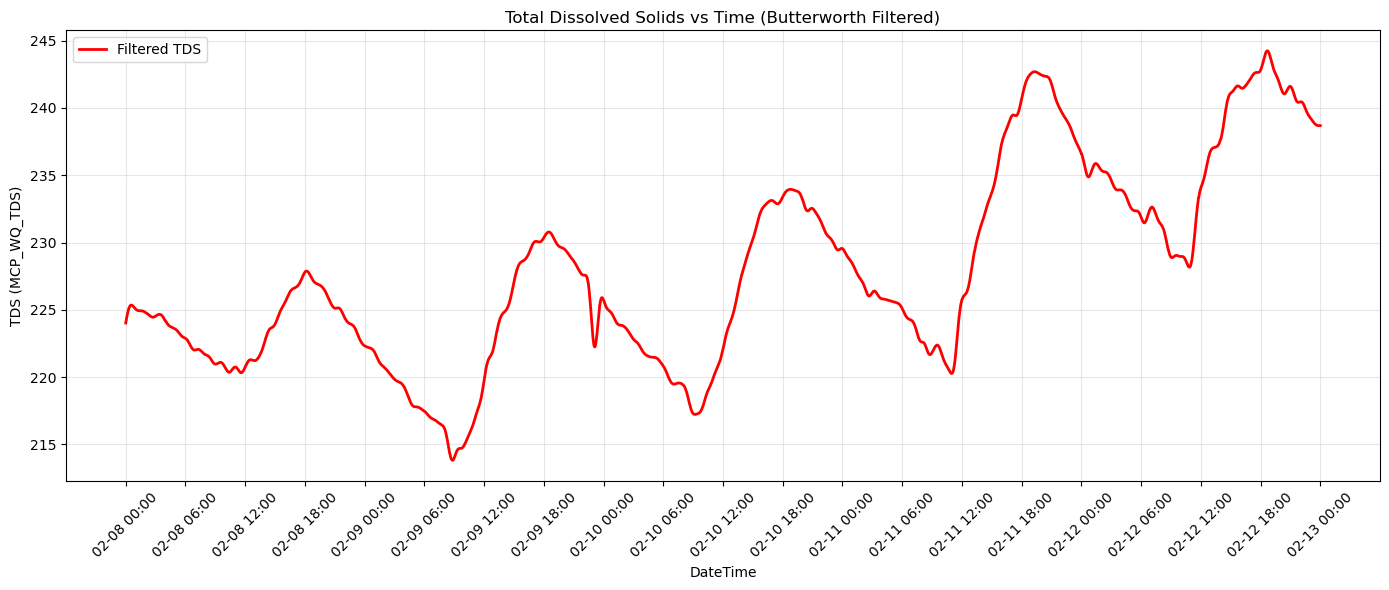


Filtering complete for MCP_WQ_TDS:
  Raw: 210.00 to 247.00
  Filtered: 213.82 to 244.25


In [6]:

# ================================
# 6. APPLY FILTER AND PLOT - TDS
# ================================
full_df = process_and_plot(
    df=full_df,
    column_name="MCP_WQ_TDS",
    sos=sos,
    title="Total Dissolved Solids vs Time (Butterworth Filtered)",
    ylabel="TDS (MCP_WQ_TDS)"
)

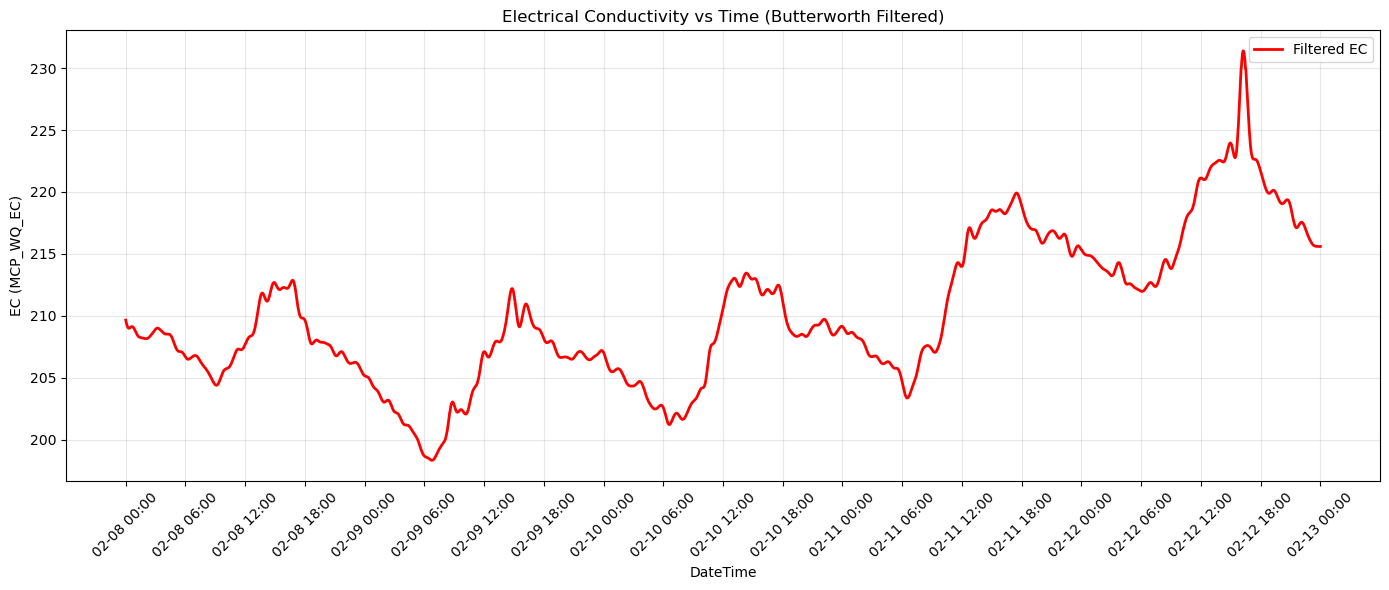


Filtering complete for MCP_WQ_EC:
  Raw: 185.00 to 261.00
  Filtered: 198.32 to 231.40


In [7]:
# ================================
# 7. APPLY FILTER AND PLOT - EC
# ================================
full_df = process_and_plot(
    df=full_df,
    column_name="MCP_WQ_EC",
    sos=sos,
    title="Electrical Conductivity vs Time (Butterworth Filtered)",
    ylabel="EC (MCP_WQ_EC)"
)


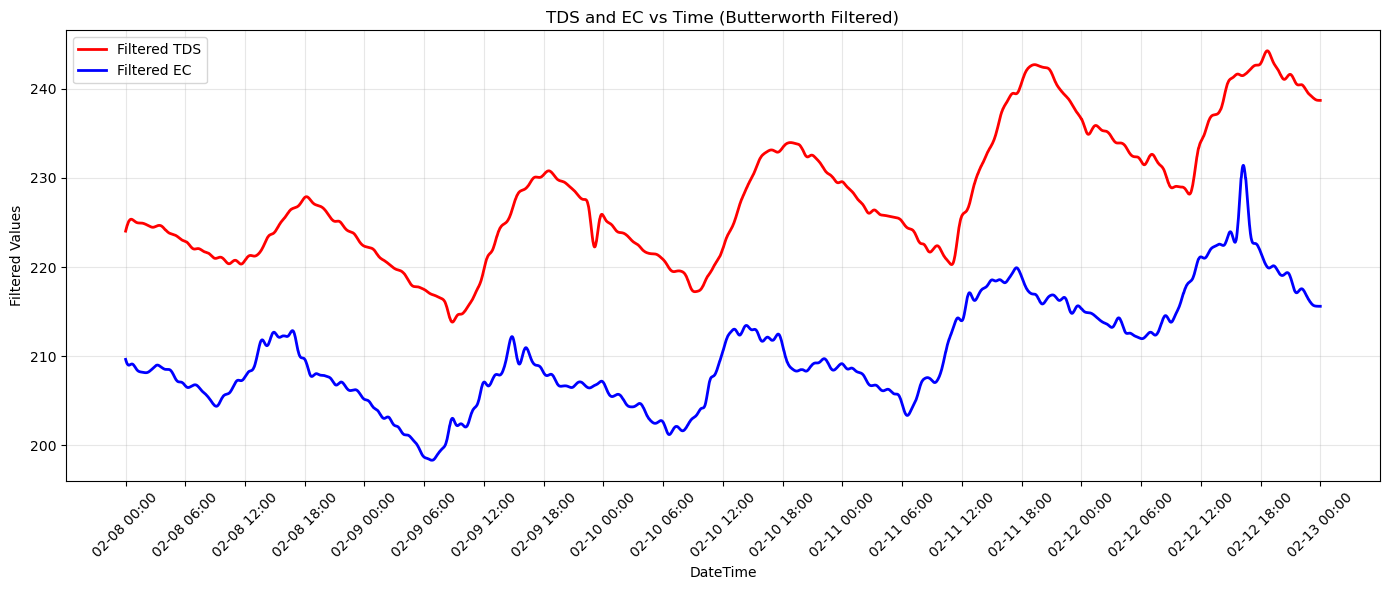


Overlay statistics:
  TDS:
    Raw: 210.00 to 247.00
    Filtered: 213.82 to 244.25
  EC:
    Raw: 185.00 to 261.00
    Filtered: 198.32 to 231.40


In [8]:
# ================================
# 8. OVERLAY TDS AND EC
# ================================
plot_overlay(
    df=full_df,
    column_names=["MCP_WQ_TDS", "MCP_WQ_EC"],
    title="TDS and EC vs Time (Butterworth Filtered)",
    ylabel="Filtered Values",
    colors=['red', 'blue'],
    labels=['TDS', 'EC']
)
